# NBA Offensive Archetype Clustering

**Research question:** Can NBA players be grouped into offensive archetypes based solely on their shot profile data — without using player names, positions, or reputation — and do the resulting clusters resemble how analysts already describe players (rim-running centers, three-point specialists, shot creators, mid-range scorers, balanced offensive players)?

**Approach:** Unsupervised clustering (e.g. K-Means, hierarchical, GMM) applied to shot-profile features pulled live from `nba_api`.

**Requires:** `pip install nba_api` (not in the default scientific-Python stack). Run locally with normal internet access — `stats.nba.com` won't be reachable from a sandboxed/offline environment.

**Notebook sections**
1. Setup & imports
2. Data collection (live `nba_api` pull)
3. Data cleaning
4. Feature engineering
5. Preprocessing (scaling)
6. Choosing the number of clusters
7. Clustering
8. Cluster evaluation & visualization
9. Comparing clusters to known archetypes
9b. Naming the clusters
10. Export for the website
11. Limitations & next steps


## 1. Setup & Imports

In [4]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

pd.set_option("display.max_columns", 50)


In [5]:
%pip install -U nba_api

Note: you may need to restart the kernel to use updated packages.


## 2. Data Collection

**Goal:** end up with one row per player (for the chosen season) containing shot location counts/efficiency and shot-creation info.

**Live data sources used below (via `nba_api`):**
- `leaguedashplayershotlocations` — shot zone FGA/FGM/FG_PCT ("By Zone": Restricted Area, In The Paint (Non-RA), Mid-Range, Left/Right Corner 3, Above the Break 3).
- `leaguedashptstats` (`pt_measure_type="Efficiency"`) — % of makes that were assisted vs. unassisted, split by 2PT/3PT, used to back out approximate assisted/unassisted make counts.

nba.com's stats API is rate-limit-y and occasionally times out — the loader below retries a few times and caches results to a local CSV so you're not re-pulling on every rerun.

**Output schema (`raw_df`), one row per player:**
- `player_id`, `player_name` (kept aside, not used as clustering features)
- `fga_rim`, `fga_paint_non_ra`, `fga_midrange`, `fga_corner3`, `fga_above_break3` — attempt counts by zone
- `fgm_rim`, `fgm_paint_non_ra`, `fgm_midrange`, `fgm_corner3`, `fgm_above_break3` — makes by zone
- `assisted_fgm`, `unassisted_fgm` — approximate makes by assist status
- `total_fga` — total field goal attempts (for filtering low-volume players)


In [10]:
import time
from pathlib import Path
from nba_api.stats.endpoints import (
    leaguedashplayershotlocations,
    leaguedashplayerstats,
    playerdashboardbyshootingsplits,
)

# nba_api hits stats.nba.com directly. It works fine from a normal machine with
# internet access, but it's picky: it wants a browser-like User-Agent, and it
# will occasionally time out or rate-limit you. Run this locally (not inside a
# network-restricted sandbox) and re-run a cell if a single request fails.

SEASON = "2025-26"          # most recently completed season as of writing this
SEASON_TYPE = "Regular Season"
CACHE_PATH = Path(f"shot_data_{SEASON.replace('-', '_')}.csv")


def _with_retries(fn, retries=3, delay=3, label="request"):
    last_error = None

    for attempt in range(1, retries + 1):
        try:
            return fn()
        except Exception as e:
            last_error = e
            print(f"{label} failed (attempt {attempt}/{retries}): {type(e).__name__}: {e}")

            if attempt < retries:
                time.sleep(delay * attempt)

    raise RuntimeError(
        f"{label} failed after {retries} attempts. "
        f"Last error: {type(last_error).__name__}: {last_error}"
    ) from last_error


def _fetch_shot_locations(season: str, season_type: str) -> pd.DataFrame:
    """Fetch zone-level shooting data from NBA.com."""

    def call():
        resp = leaguedashplayershotlocations.LeagueDashPlayerShotLocations(
            season=season,
            season_type_all_star=season_type,
            distance_range="By Zone",
            per_mode_detailed="Totals",
            measure_type_simple="Base",
            timeout=60,
        )
        return resp.get_dict()

    raw = _with_retries(call, label="Shot location fetch")

    result_set = raw["resultSets"]
    headers = result_set["headers"]
    rows = result_set["rowSet"]

    # NBA.com gives us the actual column count here.
    actual_columns = headers[1]["columnNames"]

    print(f"API returned {len(actual_columns)} columns")
    print(f"First row contains {len(rows[0])} values")

    # The first 5 columns are player information.
    base_cols = actual_columns[:5]
    metric_cols = actual_columns[5:]

    # Build readable names for the zone metrics.
    zone_names = headers[0]["columnNames"]
    column_span = headers[0]["columnSpan"]

    flat_cols = list(base_cols)

    for i, metric in enumerate(metric_cols):
        zone_index = i // column_span

        if zone_index < len(zone_names):
            zone = zone_names[zone_index]
            flat_cols.append(f"{zone}__{metric}")
        else:
            # Preserve unexpected API columns instead of crashing.
            flat_cols.append(metric)

    # Safety check.
    if len(flat_cols) != len(rows[0]):
        raise RuntimeError(
            f"Could not map NBA shot-location columns correctly: "
            f"{len(flat_cols)} names for {len(rows[0])} values."
        )

    return pd.DataFrame(rows, columns=flat_cols)


def _fetch_assist_splits(
    player_ids,
    season: str,
    season_type: str,
) -> pd.DataFrame:
    """
    Fetch season-level assisted/unassisted field-goal makes for each player.

    PlayerDashboardByShootingSplits is a player-level endpoint, so this
    requires one request per player.
    """

    results = []

    for i, player_id in enumerate(player_ids, start=1):
        def call():
            resp = playerdashboardbyshootingsplits.PlayerDashboardByShootingSplits(
                player_id=int(player_id),
                measure_type_detailed="Base",
                per_mode_detailed="Totals",
                season=season,
                season_type_playoffs=season_type,
                timeout=60,
            )

            return resp.assisted_by.get_data_frame()

        try:
            df = _with_retries(
                call,
                label=f"Assist-split fetch {player_id}",
            )

            if df.empty:
                print(f"[{i}/{len(player_ids)}] No assist data for {player_id}")
                continue

            # Keep only the fields we need.
            df = df[
                [
                    "PLAYER_ID",
                    "PLAYER_NAME",
                    "FGM",
                    "PCT_AST_FGM",
                    "PCT_UAST_FGM",
                ]
            ].copy()

            # NBA may return the percentages as either 0-1 or 0-100.
            for col in ["PCT_AST_FGM", "PCT_UAST_FGM"]:
                df[col] = pd.to_numeric(df[col], errors="coerce")

                if df[col].abs().max() > 1:
                    df[col] = df[col] / 100.0

            df["assisted_fgm"] = (
                df["FGM"] * df["PCT_AST_FGM"]
            ).round()

            df["unassisted_fgm"] = (
                df["FGM"] * df["PCT_UAST_FGM"]
            ).round()

            results.append(
                df[
                    [
                        "PLAYER_ID",
                        "assisted_fgm",
                        "unassisted_fgm",
                    ]
                ]
            )

            print(f"[{i}/{len(player_ids)}] Fetched {player_id}")

        except Exception as e:
            print(f"[{i}/{len(player_ids)}] Skipping {player_id}: {e}")

        # Be polite to stats.nba.com.
        time.sleep(0.25)

    if not results:
        raise RuntimeError("No assisted/unassisted shooting data was fetched.")

    return pd.concat(results, ignore_index=True)


def _fetch_basic_box_score(season: str, season_type: str) -> pd.DataFrame:
    """Per-game PTS/REB/AST — just for the "bio" panel on the website card,
    not used as clustering features."""

    def call():
        resp = leaguedashplayerstats.LeagueDashPlayerStats(
            season=season,
            season_type_all_star=season_type,
            per_mode_detailed="PerGame",
            measure_type_detailed_defense="Base",
            timeout=60,
        
        )
        return resp.get_data_frames()[0]

    df = _with_retries(call, label="Box score fetch")
    return df[["PLAYER_ID", "PTS", "REB", "AST"]].rename(
        columns={"PTS": "ppg", "REB": "rpg", "AST": "apg"}
    )


def load_shot_data(season: str = SEASON, season_type: str = SEASON_TYPE,
                    use_cache: bool = True) -> pd.DataFrame:
    """
    Real loader — pulls zone shot data, assist splits, team, and basic box
    score from nba_api and shapes them into the schema the rest of the
    notebook expects. Caches to a local CSV so repeat runs don't re-hit the
    API.
    """
    if use_cache and CACHE_PATH.exists():
        print(f"Loading cached shot data from {CACHE_PATH}")
        return pd.read_csv(CACHE_PATH)

    shot_df = _fetch_shot_locations(season, season_type)

    def zval(zone, metric):
        return pd.to_numeric(shot_df[f"{zone}__{metric}"], errors="coerce")

    out = pd.DataFrame({
        "player_id": shot_df["PLAYER_ID"],
        "player_name": shot_df["PLAYER_NAME"],
        "team": shot_df["TEAM_ABBREVIATION"],
        "fga_rim": zval("Restricted Area", "FGA"),
        "fgm_rim": zval("Restricted Area", "FGM"),
        "fga_paint_non_ra": zval("In The Paint (Non-RA)", "FGA"),
        "fgm_paint_non_ra": zval("In The Paint (Non-RA)", "FGM"),
        "fga_midrange": zval("Mid-Range", "FGA"),
        "fgm_midrange": zval("Mid-Range", "FGM"),
    })
    out["fga_corner3"] = zval("Left Corner 3", "FGA") + zval("Right Corner 3", "FGA")
    out["fgm_corner3"] = zval("Left Corner 3", "FGM") + zval("Right Corner 3", "FGM")
    out["fga_above_break3"] = zval("Above the Break 3", "FGA")
    out["fgm_above_break3"] = zval("Above the Break 3", "FGM")
    out["total_fga"] = out[[c for c in out.columns if c.startswith("fga_")]].sum(axis=1)

    # Assisted / unassisted makes.
    pt_df = _fetch_assist_splits(
        shot_df["PLAYER_ID"].dropna().unique(),
        season,
        season_type,
    )

    out = out.merge(
        pt_df,
        left_on="player_id",
        right_on="PLAYER_ID",
        how="left",
    ).drop(columns=["PLAYER_ID"])

    # Bio panel stats (not used in clustering)
    box_df = _fetch_basic_box_score(season, season_type)
    out = out.merge(box_df, left_on="player_id", right_on="PLAYER_ID", how="left").drop(
        columns=["PLAYER_ID"]
    )

    if use_cache:
        out.to_csv(CACHE_PATH, index=False)
        print(f"Cached shot data to {CACHE_PATH}")

    return out


raw_df = load_shot_data()
raw_df.head()


API returned 30 columns
First row contains 30 values
[1/582] Fetched 1630639
[2/582] Fetched 1631260
[3/582] Fetched 1642358
[4/582] Fetched 203932
[5/582] Fetched 1628988
[6/582] Fetched 1630174
[7/582] Fetched 1630598
[8/582] Fetched 1642846
[9/582] Fetched 1642380
[10/582] Fetched 1641737
[11/582] Fetched 1642876
[12/582] Fetched 1642349
[13/582] Fetched 201143
[14/582] Fetched 1630828
[15/582] Fetched 1627936
[16/582] No assist data for 1631457
[17/582] Fetched 1642259
[18/582] Fetched 1642918
[19/582] Fetched 1631214
[20/582] Fetched 1630578
[21/582] Fetched 1642873
[22/582] Fetched 1641708
[23/582] Fetched 1629599
[24/582] Fetched 1643158
[25/582] Fetched 203083
[26/582] Fetched 1641748
[27/582] Fetched 1629614
[28/582] Fetched 203952
[29/582] Fetched 1629014
[30/582] Fetched 1641710
[31/582] Fetched 203076
[32/582] Fetched 1630162
[33/582] Fetched 1630264
[34/582] Fetched 1641810
[35/582] Fetched 1630574
[36/582] Fetched 1642854
[37/582] Fetched 1641709
[38/582] Fetched 1630559


,player_id,player_name,team,fga_rim,fgm_rim,fga_paint_non_ra,fgm_paint_non_ra,fga_midrange,fgm_midrange,fga_corner3,fgm_corner3,fga_above_break3,fgm_above_break3,total_fga,assisted_fgm,unassisted_fgm,ppg,rpg,apg
0,1630639,A.J. Lawson,TOR,27,14,6,1,0,0,32.0,14.0,13,5,78.0,1.0,0.0,4.2,1.8,0.3
1,1630639,A.J. Lawson,TOR,27,14,6,1,0,0,32.0,14.0,13,5,78.0,2.0,0.0,4.2,1.8,0.3
2,1630639,A.J. Lawson,TOR,27,14,6,1,0,0,32.0,14.0,13,5,78.0,1.0,0.0,4.2,1.8,0.3
3,1630639,A.J. Lawson,TOR,27,14,6,1,0,0,32.0,14.0,13,5,78.0,3.0,0.0,4.2,1.8,0.3
4,1631260,AJ Green,MIL,19,11,19,10,26,9,152.0,74.0,402,158,618.0,1.0,0.0,10.4,2.7,1.9


## 3. Data Cleaning

Basic sanity checks and filtering. A common real-world choice: drop very low-volume shooters (small sample sizes make zone efficiency noisy) — e.g. require a minimum number of total field goal attempts for the season.


In [11]:
MIN_FGA = 200  # adjust once real data / sample sizes are known

df = raw_df.copy()
print("Before filtering:", df.shape)

df = df[df["total_fga"] >= MIN_FGA].reset_index(drop=True)
print("After filtering (min FGA):", df.shape)

df.isna().sum()


Before filtering: (7500, 19)
After filtering (min FGA): (5581, 19)


player_id           0
player_name         0
team                0
fga_rim             0
fgm_rim             0
fga_paint_non_ra    0
fgm_paint_non_ra    0
fga_midrange        0
fgm_midrange        0
fga_corner3         0
fgm_corner3         0
fga_above_break3    0
fgm_above_break3    0
total_fga           0
assisted_fgm        0
unassisted_fgm      0
ppg                 0
rpg                 0
apg                 0
dtype: int64

## 4. Feature Engineering

Convert raw counts into **rate-based** features so players are compared on shot *profile* (shape of their shot selection and efficiency) rather than raw volume. Planned features:

- Zone frequency shares: `pct_fga_rim`, `pct_fga_paint`, `pct_fga_midrange`, `pct_fga_corner3`, `pct_fga_above3`
- Zone efficiency: `efg_rim`, `efg_paint`, `efg_midrange`, `efg_corner3`, `efg_above3` (corner/above-break 3s weighted for the extra point)
- Aggregate shot-selection metrics: `pct_rim_plus_three` (rim + all threes, i.e. "shot quality" attempts), `three_point_rate`, `midrange_rate`
- Shot creation: `pct_assisted`, `pct_unassisted`

Feel free to expand this feature set once real tracking data (e.g. touch time, dribbles per touch, contested vs. open shots) is available.


In [12]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    zones = ["rim", "paint_non_ra", "midrange", "corner3", "above_break3"]

    # Frequency shares
    for z in zones:
        out[f"pct_fga_{z}"] = out[f"fga_{z}"] / out["total_fga"]

    # Zone efficiency (raw FG%, treat separately from value; simple version for the scaffold)
    for z in zones:
        with np.errstate(divide="ignore", invalid="ignore"):
            out[f"fgpct_{z}"] = np.where(out[f"fga_{z}"] > 0, out[f"fgm_{z}"] / out[f"fga_{z}"], np.nan)

    # Aggregate shot-selection metrics
    out["three_point_rate"] = (out["fga_corner3"] + out["fga_above_break3"]) / out["total_fga"]
    out["rim_plus_three_rate"] = (out["fga_rim"] + out["fga_corner3"] + out["fga_above_break3"]) / out["total_fga"]
    out["midrange_rate"] = out["fga_midrange"] / out["total_fga"]

    # Shot creation
    total_fgm = out[[f"fgm_{z}" for z in zones]].sum(axis=1)
    out["pct_assisted"] = out["assisted_fgm"] / total_fgm.replace(0, np.nan)
    out["pct_unassisted"] = out["unassisted_fgm"] / total_fgm.replace(0, np.nan)

    return out


features_df = engineer_features(df)

# Fill any NaN zone-efficiency values (e.g. zero attempts in a zone) with the column median
# as a simple placeholder strategy — revisit once real data volumes are known.
fgpct_cols = [c for c in features_df.columns if c.startswith("fgpct_")]
features_df[fgpct_cols] = features_df[fgpct_cols].fillna(features_df[fgpct_cols].median())

features_df[["player_name"] + fgpct_cols + ["three_point_rate", "rim_plus_three_rate", "pct_assisted"]].head()


,player_name,fgpct_rim,fgpct_paint_non_ra,fgpct_midrange,fgpct_corner3,fgpct_above_break3,three_point_rate,rim_plus_three_rate,pct_assisted
0,AJ Green,0.578947,0.526316,0.346154,0.486842,0.393035,0.89644,0.927184,0.003817
1,AJ Green,0.578947,0.526316,0.346154,0.486842,0.393035,0.89644,0.927184,0.011450
2,AJ Green,0.578947,0.526316,0.346154,0.486842,0.393035,0.89644,0.927184,0.064885
3,AJ Green,0.578947,0.526316,0.346154,0.486842,0.393035,0.89644,0.927184,0.003817
4,AJ Green,0.578947,0.526316,0.346154,0.486842,0.393035,0.89644,0.927184,0.007634


## 5. Preprocessing

Select the feature columns that will actually go into clustering (exclude IDs, names, and — importantly — any ground-truth/reference labels), then standardize since K-Means and related methods are sensitive to feature scale.


In [13]:
FEATURE_COLS = [
    "pct_fga_rim", "pct_fga_paint_non_ra", "pct_fga_midrange", "pct_fga_corner3", "pct_fga_above_break3",
    "fgpct_rim", "fgpct_paint_non_ra", "fgpct_midrange", "fgpct_corner3", "fgpct_above_break3",
    "three_point_rate", "rim_plus_three_rate", "midrange_rate",
    "pct_assisted", "pct_unassisted",
]

X = features_df[FEATURE_COLS].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURE_COLS, index=features_df.index)
X_scaled_df.describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
pct_fga_rim,-2.164348e-16,1.00009,-1.767915,4.400833
pct_fga_paint_non_ra,1.043980e-16,1.00009,-2.225981,4.533055
pct_fga_midrange,-7.129617e-17,1.00009,-1.267080,5.498364
pct_fga_corner3,-5.092584e-17,1.00009,-1.490947,4.088723
pct_fga_above_break3,-1.374998e-16,1.00009,-2.094405,2.490152
fgpct_rim,-1.960645e-16,1.00009,-3.352480,2.730064
fgpct_paint_non_ra,9.675909e-16,1.00009,-4.957546,6.630005
fgpct_midrange,6.874988e-17,1.00009,-3.147460,4.932563
fgpct_corner3,-8.148134e-17,1.00009,-3.307425,5.347413
fgpct_above_break3,-2.240737e-16,1.00009,-4.054819,8.143598


## 6. Choosing the Number of Clusters

Use the elbow method (inertia) and silhouette score across a range of `k` values. Note up front: **the choice of k is inherently subjective** — this is one of the documented limitations of the project, not something these plots definitively resolve.


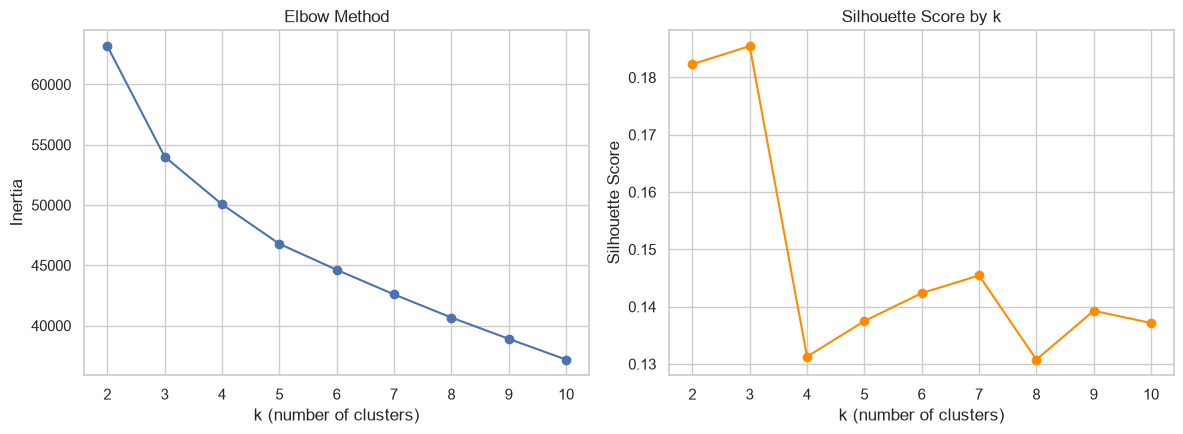

In [14]:
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.show()


## 7. Clustering

Fit K-Means with a chosen `k` (update `N_CLUSTERS` based on the elbow/silhouette plots above and domain judgment — e.g. 5 to roughly match the archetypes named in the proposal). Also scaffolds two alternative algorithms (Gaussian Mixture, Agglomerative) for later comparison/robustness checks.


In [15]:
N_CLUSTERS = 5  # placeholder — revisit based on Section 6 and domain knowledge

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
features_df["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

# Alternative algorithms for later robustness comparison
gmm = GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE)
features_df["cluster_gmm"] = gmm.fit_predict(X_scaled)

agglo = AgglomerativeClustering(n_clusters=N_CLUSTERS)
features_df["cluster_agglo"] = agglo.fit_predict(X_scaled)

features_df["cluster_kmeans"].value_counts().sort_index()


cluster_kmeans
0    1182
1     782
2    1129
3    1781
4     707
Name: count, dtype: int64

## 8. Cluster Evaluation & Visualization

- Quantitative: silhouette score, Davies-Bouldin index for the chosen K-Means solution.
- Visual: project the scaled features into 2D via PCA and plot clusters, plus a heatmap of average feature values per cluster ("cluster profiles") to help interpret what each cluster represents.


Silhouette score: 0.137
Davies-Bouldin index: 1.812  (lower is better)


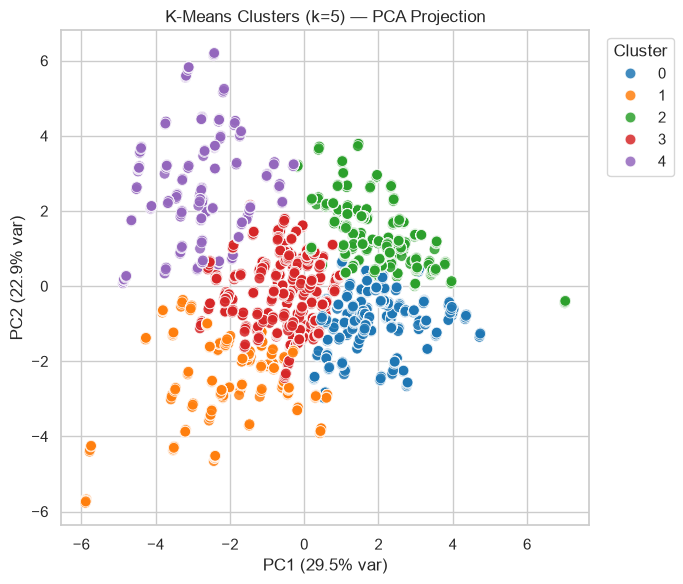

In [16]:
sil = silhouette_score(X_scaled, features_df["cluster_kmeans"])
db = davies_bouldin_score(X_scaled, features_df["cluster_kmeans"])
print(f"Silhouette score: {sil:.3f}")
print(f"Davies-Bouldin index: {db:.3f}  (lower is better)")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_scaled)
features_df["pca_1"], features_df["pca_2"] = pca_coords[:, 0], pca_coords[:, 1]

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=features_df, x="pca_1", y="pca_2",
    hue="cluster_kmeans", palette="tab10", s=60, alpha=0.85,
)
plt.title(f"K-Means Clusters (k={N_CLUSTERS}) — PCA Projection")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


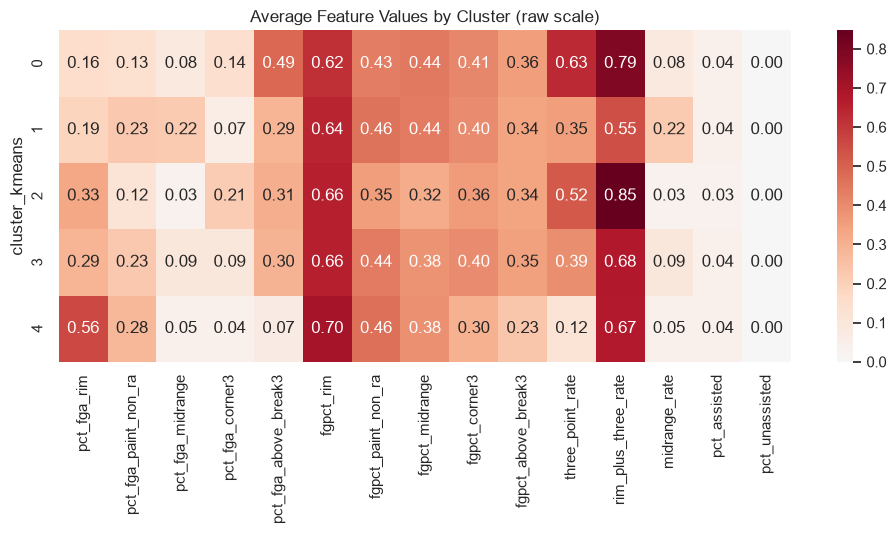

,pct_fga_rim,pct_fga_paint_non_ra,pct_fga_midrange,pct_fga_corner3,pct_fga_above_break3,fgpct_rim,fgpct_paint_non_ra,fgpct_midrange,fgpct_corner3,fgpct_above_break3,three_point_rate,rim_plus_three_rate,midrange_rate,pct_assisted,pct_unassisted
cluster_kmeans,,,,,,,,,,,,,,,
0,0.155353,0.134148,0.079686,0.144531,0.486282,0.619635,0.433494,0.444262,0.410496,0.357043,0.630813,0.786166,0.079686,0.042163,0.0
1,0.191215,0.230734,0.223583,0.065334,0.289134,0.643069,0.461757,0.438757,0.399736,0.341093,0.354468,0.545683,0.223583,0.041811,0.0
2,0.329857,0.118174,0.034839,0.211840,0.305290,0.659870,0.354942,0.316399,0.357440,0.337530,0.517130,0.846987,0.034839,0.034784,0.0
3,0.286462,0.229441,0.093260,0.093093,0.297744,0.660009,0.441036,0.379871,0.402389,0.348165,0.390837,0.677299,0.093260,0.044291,0.0
4,0.557115,0.281852,0.045323,0.043897,0.071813,0.704368,0.463991,0.384738,0.303765,0.233722,0.115710,0.672825,0.045323,0.040031,0.0


In [17]:
cluster_profile = features_df.groupby("cluster_kmeans")[FEATURE_COLS].mean()

plt.figure(figsize=(10, 4 + 0.3 * N_CLUSTERS))
sns.heatmap(cluster_profile, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Average Feature Values by Cluster (raw scale)")
plt.tight_layout()
plt.show()

cluster_profile


## 9. Comparing Clusters to Known Archetypes

Once real, labeled data (or reasonable manual archetype tags for a subset of well-known players) is available, this section should:

- Cross-tabulate discovered clusters against analyst-assigned archetypes (confusion-matrix style) to see how well they align.
- Spot-check a handful of well-known players per cluster to sanity-check whether the grouping "makes basketball sense."
- Note any surprising groupings (e.g. players who don't fit their expected archetype) as interesting findings rather than errors.

The synthetic data includes a `true_archetype_for_reference_only` column (not used in clustering) purely so this comparison logic can be tested now; drop or replace it once real archetype labels are sourced.


In [18]:
if "true_archetype_for_reference_only" in features_df.columns:
    comparison = pd.crosstab(
        features_df["true_archetype_for_reference_only"],
        features_df["cluster_kmeans"],
    )
    display(comparison)
else:
    print(
        "No ground-truth archetype labels on real data — that's expected. "
        "Use the cluster_profile heatmap above (and the player spot-checks "
        "below) to decide what each cluster number actually represents."
    )


No ground-truth archetype labels on real data — that's expected. Use the cluster_profile heatmap above (and the player spot-checks below) to decide what each cluster number actually represents.


In [19]:
# Spot-check a few players per cluster
for c in sorted(features_df["cluster_kmeans"].unique()):
    sample = features_df.loc[features_df["cluster_kmeans"] == c, "player_name"].head(5).tolist()
    print(f"Cluster {c}: {sample}")


Cluster 0: ['AJ Green', 'AJ Green', 'AJ Green', 'AJ Green', 'AJ Green']
Cluster 1: ['Ace Bailey', 'Ace Bailey', 'Ace Bailey', 'Ace Bailey', 'Ace Bailey']
Cluster 2: ['Aaron Wiggins', 'Aaron Wiggins', 'Aaron Wiggins', 'Aaron Wiggins', 'Aaron Wiggins']
Cluster 3: ['Aaron Gordon', 'Aaron Gordon', 'Aaron Gordon', 'Aaron Gordon', 'Aaron Gordon']
Cluster 4: ['Alperen Sengun', 'Alperen Sengun', 'Alperen Sengun', 'Alperen Sengun', 'Alperen Sengun']


## 9b. Naming the Clusters

K-Means only gives you cluster *numbers* — turning `cluster_kmeans == 3` into
something like "Rim Runner" is a manual, interpretive step. Read the
`cluster_profile` heatmap from Section 8 and the spot-checked players above:
whichever cluster has high `pct_fga_rim` and high `fgpct_rim` is probably your
rim runners, whichever has high `three_point_rate` and low `pct_assisted` is
probably your shot creators, and so on.

Fill in `CLUSTER_NAMES` below to match what you're actually seeing — cluster
numbers are not stable across reruns (they can shuffle every time you refit),
so this has to be redone by eye each time you retrain, not hardcoded once.


In [20]:
# Update this after reading the cluster_profile heatmap + spot-checked players
# above. Keys must cover every value in features_df["cluster_kmeans"].unique().
CLUSTER_NAMES = {
    0: "Balanced Wing",
    1: "Midrange Scorer",
    2: "Three-and-D",
    3: "Rim Runner",
    4: "Shot Creator",
}

missing = set(features_df["cluster_kmeans"].unique()) - set(CLUSTER_NAMES)
if missing:
    raise ValueError(f"CLUSTER_NAMES is missing an entry for cluster(s): {missing}")

features_df["archetype"] = features_df["cluster_kmeans"].map(CLUSTER_NAMES)
features_df[["player_name", "cluster_kmeans", "archetype"]].head(10)


,player_name,cluster_kmeans,archetype
0,AJ Green,0,Balanced Wing
1,AJ Green,0,Balanced Wing
2,AJ Green,0,Balanced Wing
3,AJ Green,0,Balanced Wing
4,AJ Green,0,Balanced Wing
5,AJ Green,0,Balanced Wing
6,AJ Green,0,Balanced Wing
7,AJ Green,0,Balanced Wing
8,AJ Green,0,Balanced Wing
9,AJ Green,0,Balanced Wing


## 10. Export for the Website

Writes a JSON file the clubhouse site's Sports Lab page reads directly.


In [21]:
import json
from pathlib import Path

EXPORT_COLS = [
    "player_id", "player_name", "team", "archetype", "cluster_kmeans",
    "pct_fga_rim", "pct_fga_paint_non_ra", "pct_fga_midrange",
    "pct_fga_corner3", "pct_fga_above_break3",
    "fgpct_rim", "fgpct_paint_non_ra", "fgpct_midrange",
    "fgpct_corner3", "fgpct_above_break3",
    "three_point_rate", "rim_plus_three_rate", "pct_assisted", "total_fga",
    "ppg", "rpg", "apg",
]

# Some of these (team, ppg/rpg/apg) ride along from raw_df/df rather than
# being engineered features — make sure they survived the merges/filters.
missing_cols = [c for c in EXPORT_COLS if c not in features_df.columns]
if missing_cols:
    raise KeyError(
        f"Missing expected column(s) for export: {missing_cols}. "
        "Did the loader in Section 2 run successfully with team/box-score data?"
    )

export_df = features_df[EXPORT_COLS].round(3)

payload = {
    "season": SEASON,
    "generated_from": "nba_shot_archetype_clustering.ipynb",
    "players": export_df.to_dict(orient="records"),
}

OUTPUT_PATH = Path("player-archetypes.json")
with open(OUTPUT_PATH, "w") as f:
    json.dump(payload, f, indent=2)

print(f"Wrote {len(payload['players'])} players to {OUTPUT_PATH.resolve()}")
print("Copy this file into the site repo at public/data/player-archetypes.json")


Wrote 5581 players to /Users/benzeng/Desktop/Ben/Sports Portfolio/sports-analytics-portfolio/player-archetypes.json
Copy this file into the site repo at public/data/player-archetypes.json


## 11. Limitations & Next Steps

**Documented limitations:**
- **Subjectivity of k.** The number of clusters is a modeling choice guided by elbow/silhouette diagnostics and domain interpretation, not a single "correct" answer — different k values will emphasize coarser or finer-grained archetypes.
- **Team and system context.** A player's shot profile is shaped by their role, offensive scheme, and teammates, not just individual skill or tendency — the same player could look different on a different team.
- **Season-level aggregation.** Aggregating across a season can obscure within-season changes (role changes, injuries, trades).
- **Synthetic placeholder data.** Results in this scaffold are generated from simulated data and are not meant to be interpreted basketball-wise; they exist only to validate the pipeline.
- **Sample size per player.** Very low-volume shooters in certain zones produce noisy efficiency estimates even after the `MIN_FGA` filter.

**Next steps:**
1. Wire in real data via `nba_api` (or an alternate source) in Section 2, matching the existing schema.
2. Revisit `MIN_FGA` and zone definitions against actual data availability.
3. Try alternative clustering algorithms (GMM, hierarchical — already scaffolded) and compare stability/agreement with K-Means.
4. Bring in a real reference archetype labeling (e.g. hand-labeled by basketball knowledge, or sourced from existing public archetype work) for Section 9.
5. Consider adding tracking-data features (touch time, dribbles per touch, contested rate) if available, to enrich beyond pure shot-location data.
